In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import pprint

In [3]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM

In [4]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x7e86368c6c80>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x7e863673cb50>, root_client=<openai.OpenAI object at 0x7e864864bc10>, root_async_client=<openai.AsyncOpenAI object at 0x7e86368c6cb0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the Graph state

State is the object that is passed between nodes in the graph.

In [5]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, AnyMessage # type: ignore
import operator
from IPython.display import Image, display

In [6]:
class AgentState(TypedDict):
    input: str
    agent_outcome: List[AnyMessage]
    chat_history: Annotated[list, operator.add]

The `AgentState` schema represents the structure and type of data that graph will use.


`TypeDict` is a Python dictionary subclass that allows to specify keys and their corresponding value types. These can be used for type-checking, however they are not enforced at runtime. 

If validation is required, use `BaseClass` from `Pydantic`

### Define the agent (node)

In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    print(data)
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant"
                "\nUser Query: {input}"
            ),
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    agent = prompt | llm
    result = agent.invoke(data)
    return {
                'agent_outcome': [result],
                'chat_history': ["User: " + data['input'] + "\n AI Message: " + result.content],
            }

### Defining the workflow (graph)

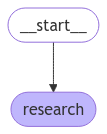

In [8]:
from langgraph.graph import END, StateGraph

## Initialising the workflow
workflow = StateGraph(AgentState)

## Adding node (agent) to the graph (workflow)
workflow.add_node("research", research_agent)

## Setting the entry point of the graph
workflow.set_entry_point("research")

## Compiling the graph
app = workflow.compile()
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [9]:
inputs = {
    "input": "What are Small Language Models?",
}

app.invoke(input=inputs)

{'input': 'What are Small Language Models?', 'chat_history': []}


{'input': 'What are Small Language Models?',
 'agent_outcome': [AIMessage(content='Small Language Models (SLMs) refer to natural language processing models that are smaller in size and complexity compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which can make them faster to train and deploy, and they often require less computational power and memory.\n\nHere are some key characteristics and advantages of Small Language Models:\n\n1. **Size and Complexity**: SLMs usually have fewer layers and parameters, which makes them less resource-intensive. This can be beneficial for applications where computational resources are limited.\n\n2. **Speed**: Due to their smaller size, SLMs can process text more quickly, making them suitable for real-time applications or environments where latency is a concern.\n\n3. **Efficiency**: They can be more efficient in terms of energy consumption, which is important for mobile devices or edge computin

`invoke()` method is used to run the workflow. It runs the entire graph (workflow) synchronously. 

It takes the input data and returns the final state of the workflow. 

The final state contains the output of the last agent that was executed in the workflow.

In [10]:
for s in app.stream(input=inputs):
    pprint.pp(s)
    print(list(s.values())[0]['agent_outcome'][0].content)
    print("-----"*20)

{'input': 'What are Small Language Models?', 'chat_history': []}
{'research': {'agent_outcome': [AIMessage(content='Small Language Models (SLMs) refer to natural language processing models that are smaller in size and complexity compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which can make them faster to train and deploy, and they often require less computational power and memory.\n\nHere are some key characteristics and advantages of small language models:\n\n1. **Size and Complexity**: SLMs usually have fewer layers and parameters, which makes them less resource-intensive. This can be beneficial for applications where computational resources are limited.\n\n2. **Speed**: Due to their smaller size, SLMs can process text more quickly, making them suitable for real-time applications or environments where latency is a concern.\n\n3. **Efficiency**: They can be more efficient in terms of energy consumption, which is important fo

In [11]:
def stream_app_updates(user_input: str, chat_history: list):
    inputs = {
        "input": user_input,
        "chat_history": chat_history
    }
    for event in app.stream(input=inputs):
        for value in event.values():
            response = value["agent_outcome"][-1].content
            conv = value["chat_history"][-1]
    return response, conv

chat_history = []
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        response, conv = stream_app_updates(user_input, chat_history)
    except:
        # fallback if input() is not available
        print("User: " + user_input)
        response, conv = stream_app_updates(user_input, chat_history)
        break
    print("Assistant:", response)
    chat_history.append(conv)

{'input': 'large language model agents', 'chat_history': []}
Assistant: Large language model agents refer to advanced AI systems that utilize large language models (LLMs) to perform various tasks, such as natural language understanding, text generation, conversation, and more. These agents can be designed to interact with users, provide information, assist in decision-making, and automate tasks across different domains.

Key characteristics of large language model agents include:

1. **Natural Language Processing (NLP)**: They can understand and generate human language, making them capable of engaging in conversations, answering questions, and providing explanations.

2. **Contextual Understanding**: LLM agents can maintain context over a conversation, allowing for more coherent and relevant interactions.

3. **Adaptability**: They can be fine-tuned or customized for specific applications, industries, or user needs, enhancing their effectiveness in particular tasks.

4. **Multimodal Ca